# Comparing X-MACE Latent Spaces With PCA

Uses the new updated classes. Runs PCA on the latent spaces to visualise how it looks like

## 1. Setup And Load Data

In [12]:
import os
from pathlib import Path

TUTORIAL_ROOT = Path(os.getcwd())
DATA_DIR = TUTORIAL_ROOT / "data" / "xyz"
OUTPUT_DIR = TUTORIAL_ROOT / "_outputs" / "04_pca"
GRAPH_DIR = OUTPUT_DIR / "graphs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

ETHENE_22_FILE = DATA_DIR / "A01_ethene_grid_static.xyz"
PROPENE_22_FILE = DATA_DIR / "A02_propene_grid_static.xyz"
PROPENE_44_FILE = DATA_DIR / "casscf_44_propene_full.xyz"

MPLCONFIGDIR = OUTPUT_DIR / "matplotlib_cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import ase.io
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import torch
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import extract_latent_space
from mace.training import Trainer, initialise_autoencoder

DEVICE = torch.device("cpu")
R_MAX = 5.0
BATCH_SIZE = 16
VALID_FRACTION = 0.2
SEED = 123
LATENT_DIM = 16
MAX_EPOCHS = 2048

np.random.seed(SEED)
torch.manual_seed(SEED)

loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0, forces_weight=5.0, dipoles_weight=0.0,
    nacs_weight=0.0, socs_weight=0.0,
).to(DEVICE)

trainer = Trainer(
    max_epochs=MAX_EPOCHS, early_stopping=True, patience=20,
    restore_best=True, device=DEVICE, verbose=True,
)

The 4e4o propene dataset contains 500 geometries, so the first 500 geometries from each dataset are used for a consistent comparison.

In [2]:
atoms_propene_44 = ase.io.read(PROPENE_44_FILE, index=":")
N_GEOMETRIES = len(atoms_propene_44)

atoms_ethene_22 = ase.io.read(ETHENE_22_FILE, index=f":{N_GEOMETRIES}")
atoms_propene_22 = ase.io.read(PROPENE_22_FILE, index=f":{N_GEOMETRIES}")

atoms_by_name = {
    "ethene_22": atoms_ethene_22,
    "propene_22": atoms_propene_22,
    "propene_44": atoms_propene_44,
}

{name: len(atoms_list) for name, atoms_list in atoms_by_name.items()}

{'ethene_22': 500, 'propene_22': 500, 'propene_44': 500}

## 2. Build Train And Validation Loaders

Each dataset uses an independent 80/20 split and its own builder metadata. The full ordered loaders are retained for latent-space extraction.

In [ ]:
train_atoms = {}
valid_atoms = {}
builders = {}
train_loaders = {}
valid_loaders = {}
full_loaders = {}

for name, atoms_list in atoms_by_name.items():
    # Train test split 
    train_atoms[name], valid_atoms[name] = train_test_split(
        atoms_list, test_size=VALID_FRACTION, random_state=SEED, shuffle=True
    )

    # Builder 
    builder = AtomDataLoaderBuilder(
        cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
    )
    builders[name] = builder
    train_loaders[name] = builder.load(
        train_atoms[name], batch_size=BATCH_SIZE, shuffle=True
    )
    valid_loaders[name] = builder.load(
        valid_atoms[name], batch_size=BATCH_SIZE, shuffle=False
    )

    # Here we define a full dataloader for the latent space inspection 
    full_loaders[name] = builder.load(
        atoms_list, batch_size=BATCH_SIZE, shuffle=False
    )

{
    name: {"train": len(train_atoms[name]), "valid": len(valid_atoms[name])}
    for name in atoms_by_name
}

{'ethene_22': {'train': 400, 'valid': 100},
 'propene_22': {'train': 400, 'valid': 100},
 'propene_44': {'train': 400, 'valid': 100}}

## 3. Train Three Equivalent Models

All models use the lightweight 16D preset, the same optimizer settings, and the same trainer configuration.

In [4]:
models = {}
histories = {}

for name in atoms_by_name:
    print(f"\nTraining {name}")
    torch.manual_seed(SEED)

    model = initialise_autoencoder(
        builders[name].get_metadata(), preset="lightweight", latent_dim=LATENT_DIM
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)
    models[name], histories[name] = trainer.train_model(
        model, train_loaders[name], valid_loaders[name], optimizer, loss_fn
    )

model_ethene_22 = models["ethene_22"]
model_propene_22 = models["propene_22"]
model_propene_44 = models["propene_44"]


Training ethene_22


/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=166.615208 | valid_loss=140.263830
Epoch 002 | train_loss=147.886210 | valid_loss=104.557686
Epoch 003 | train_loss=82.490880 | valid_loss=49.498937
Epoch 004 | train_loss=37.801988 | valid_loss=28.336860
Epoch 005 | train_loss=25.592764 | valid_loss=24.620697
Epoch 006 | train_loss=25.668376 | valid_loss=21.542499
Epoch 007 | train_loss=22.055625 | valid_loss=19.727468
Epoch 008 | train_loss=21.172256 | valid_loss=19.796956
Epoch 009 | train_loss=20.309711 | valid_loss=19.629693
Epoch 010 | train_loss=20.221924 | valid_loss=17.835976
Epoch 011 | train_loss=21.176409 | valid_loss=24.588678
Epoch 012 | train_loss=20.864504 | valid_loss=18.050521
Epoch 013 | train_loss=19.487182 | valid_loss=17.885493
Epoch 014 | train_loss=18.918468 | valid_loss=17.132679
Epoch 015 | train_loss=18.625619 | valid_loss=18.044591
Epoch 016 | train_loss=18.702892 | valid_loss=16.451060
Epoch 017 | train_loss=18.142399 | valid_loss=16.784461
Epoch 018 | train_loss=18.197889 | valid_los

/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=112.224398 | valid_loss=111.879350
Epoch 002 | train_loss=102.375658 | valid_loss=110.868453
Epoch 003 | train_loss=100.166335 | valid_loss=106.330837
Epoch 004 | train_loss=88.569343 | valid_loss=82.726431
Epoch 005 | train_loss=67.611800 | valid_loss=59.520475
Epoch 006 | train_loss=44.323740 | valid_loss=32.459120
Epoch 007 | train_loss=29.456442 | valid_loss=28.228015
Epoch 008 | train_loss=27.169609 | valid_loss=25.776777
Epoch 009 | train_loss=25.712899 | valid_loss=24.164120
Epoch 010 | train_loss=25.123960 | valid_loss=23.406729
Epoch 011 | train_loss=24.741347 | valid_loss=22.786483
Epoch 012 | train_loss=23.521203 | valid_loss=22.303587
Epoch 013 | train_loss=23.891547 | valid_loss=23.067429
Epoch 014 | train_loss=23.419836 | valid_loss=21.660380
Epoch 015 | train_loss=22.546851 | valid_loss=20.785106
Epoch 016 | train_loss=22.589069 | valid_loss=22.116880
Epoch 017 | train_loss=22.215165 | valid_loss=21.707072
Epoch 018 | train_loss=23.549502 | valid_l

/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=95.031742 | valid_loss=98.971043
Epoch 002 | train_loss=89.214153 | valid_loss=97.291582
Epoch 003 | train_loss=88.060902 | valid_loss=94.789911
Epoch 004 | train_loss=75.938231 | valid_loss=65.965212
Epoch 005 | train_loss=49.086331 | valid_loss=38.603197
Epoch 006 | train_loss=27.320373 | valid_loss=23.508626
Epoch 007 | train_loss=16.748629 | valid_loss=17.069927
Epoch 008 | train_loss=14.073489 | valid_loss=12.420168
Epoch 009 | train_loss=12.370189 | valid_loss=13.129662
Epoch 010 | train_loss=11.134776 | valid_loss=11.299182
Epoch 011 | train_loss=10.769825 | valid_loss=10.220809
Epoch 012 | train_loss=10.308041 | valid_loss=9.528708
Epoch 013 | train_loss=9.309867 | valid_loss=9.697253
Epoch 014 | train_loss=9.077666 | valid_loss=8.802874
Epoch 015 | train_loss=8.832306 | valid_loss=8.427516
Epoch 016 | train_loss=8.422696 | valid_loss=9.244464
Epoch 017 | train_loss=8.332444 | valid_loss=7.908947
Epoch 018 | train_loss=8.118777 | valid_loss=8.210284
Epoch

## 4. Extract The Three 16D Latent Spaces

The full dataloaders fro before use `shuffle=False`, so each row is aligned to or follows the same order as the input atoms list order 

In [6]:
latent_ethene_22 = extract_latent_space(
    model_ethene_22, full_loaders["ethene_22"], device=DEVICE
)
latent_propene_22 = extract_latent_space(
    model_propene_22, full_loaders["propene_22"], device=DEVICE
)
latent_propene_44 = extract_latent_space(
    model_propene_44, full_loaders["propene_44"], device=DEVICE
)

## 5. Individual PCA

For each of the 3 latent spaces we trivially try to visualise it by
running PCA individually 
The Axis will be different so not too much interpretability but still a cool ish visual

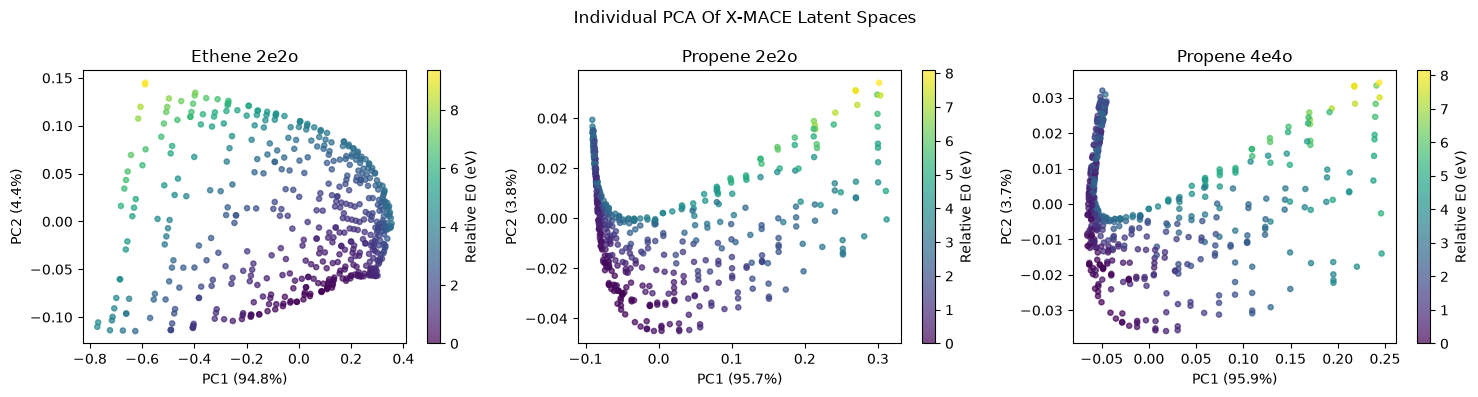

In [ ]:
pca_ethene_22 = PCA(n_components=2)
pca_propene_22 = PCA(n_components=2)
pca_propene_44 = PCA(n_components=2)

# Fit PCA on each of the latent space vectors
projected_ethene_22 = pca_ethene_22.fit_transform(latent_ethene_22)
projected_propene_22 = pca_propene_22.fit_transform(latent_propene_22)
projected_propene_44 = pca_propene_44.fit_transform(latent_propene_44)

dataset_names = ["ethene_22", "propene_22", "propene_44"]

# Get the energies from the batch
reference_energies = {}
for name in dataset_names:
    energy_batches = [batch["energy"].detach().cpu() for batch in full_loaders[name]]
    reference_energies[name] = torch.cat(energy_batches).numpy()

relative_ground_energies = []
for name in dataset_names:
    ground_energy = reference_energies[name][:, 0]
    relative_ground_energies.append(ground_energy - ground_energy.min())

projections = [projected_ethene_22, projected_propene_22, projected_propene_44]
pca_models = [pca_ethene_22, pca_propene_22, pca_propene_44]
titles = ["Ethene 2e2o", "Propene 2e2o", "Propene 4e4o"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, projected, pca, title, energy in zip(
    axes, projections, pca_models, titles, relative_ground_energies
):
    variance = 100 * pca.explained_variance_ratio_
    scatter = ax.scatter(
        projected[:, 0], projected[:, 1], c=energy, cmap="viridis", s=14, alpha=0.7
    )
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({variance[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({variance[1]:.1f}%)")
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Relative E0 (eV)")

fig.suptitle("Individual PCA Of X-MACE Latent Spaces")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "individual_pca.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Aligned PCA

Propene 2e2o is used as the reference latent space. Orthogonal Procrustes rotates or reflects the centered ethene 2e2o and propene 4e4o spaces toward that reference without rescaling them. 
This is because latent spaces learned by the model can always be rotated 
or reflected internally. This mapping is trivial for the decoder. What 
matters more is the structure that the latent space has which will probably
affect the kind of sampling or architecture we use.

The aligned spaces are then projected using one shared PCA basis. Every shared or same point in this common axis 2D PCA is pretty much gonna be the exact point in 16D that match because the variance along each axis is quite high in this example 

First we try to align all 3 datasets to see what kind of structures emerge 

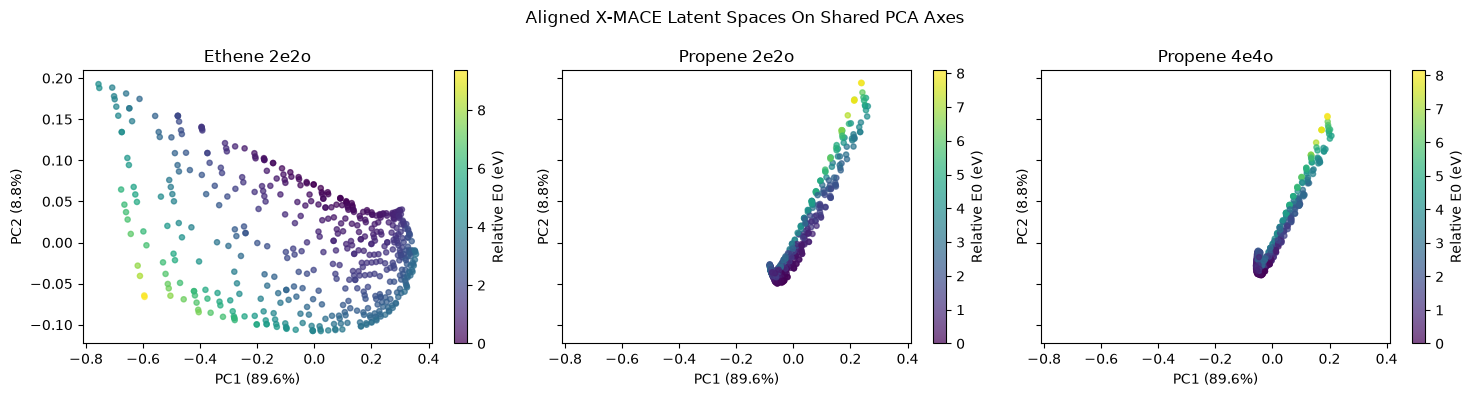

In [17]:
# Center the latent space data first 
reference_mean = latent_propene_22.mean(axis=0, keepdims=True)
reference_centered = latent_propene_22 - reference_mean
ethene_centered = latent_ethene_22 - latent_ethene_22.mean(axis=0, keepdims=True)
propene_44_centered = latent_propene_44 - latent_propene_44.mean(axis=0, keepdims=True)

# Scikit library does the rotation and optimisation 
rotation_ethene_22, _ = orthogonal_procrustes(ethene_centered, reference_centered)
rotation_propene_44, _ = orthogonal_procrustes(propene_44_centered, reference_centered)

# Get the aligned subspace 
aligned_ethene_22 = ethene_centered @ rotation_ethene_22 + reference_mean
aligned_propene_22 = latent_propene_22.copy()
aligned_propene_44 = propene_44_centered @ rotation_propene_44 + reference_mean

# Concat all 3 subspace together to form one mega 16x1500 subspace 
aligned_latent_spaces = np.concatenate(
    [aligned_ethene_22, aligned_propene_22, aligned_propene_44], axis=0
)

# PCA on the mega subspace 
shared_pca = PCA(n_components=2)
shared_pca.fit(aligned_latent_spaces)

# Use the same PCA axis on the original latent spaces 
aligned_projected_ethene_22 = shared_pca.transform(aligned_ethene_22)
aligned_projected_propene_22 = shared_pca.transform(aligned_propene_22)
aligned_projected_propene_44 = shared_pca.transform(aligned_propene_44)

# Plot the projections 
aligned_projections = [
    aligned_projected_ethene_22,
    aligned_projected_propene_22,
    aligned_projected_propene_44,
]
shared_variance = 100 * shared_pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, projected, title, energy in zip(
    axes, aligned_projections, titles, relative_ground_energies
):
    scatter = ax.scatter(
        projected[:, 0], projected[:, 1], c=energy, cmap="viridis", s=14, alpha=0.7
    )
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({shared_variance[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({shared_variance[1]:.1f}%)")
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Relative E0 (eV)")

fig.suptitle("Aligned X-MACE Latent Spaces On Shared PCA Axes")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "aligned_pca.png", dpi=200, bbox_inches="tight")
plt.show()

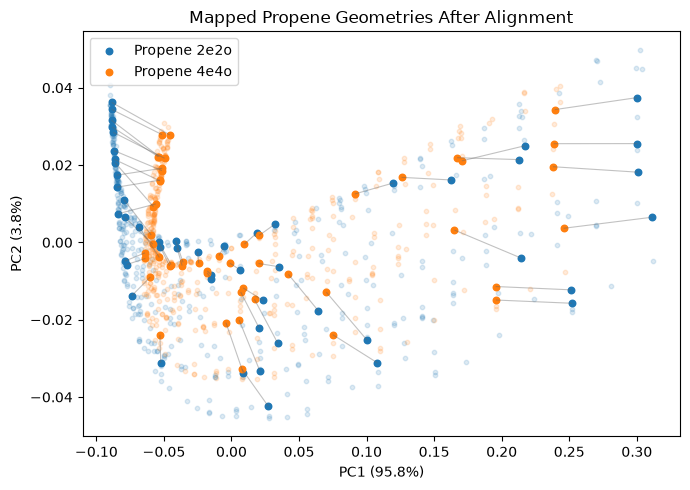

In [ ]:
"""
From above the latent space for ethene vs propene seems to differ quite abit. 
Here we just plot propene with 2 levels of theory to test it out 

Visuaise the aligned PCA points by connecting lines to each other 
Because the axis is shared, every geometry is the exact point in the 
collapsed space. 
The connections also represent identical geometries but with different 
levels of theory used to calculate them 
"""
# Stack only the two propene latent spaces 
stacked_propene_latent_spaces = np.vstack(
    [aligned_propene_22, aligned_propene_44]
)

# Re run PCA to get axis
propene_shared_pca = PCA(n_components=2)
propene_shared_pca.fit(stacked_propene_latent_spaces)

# Get the projected latent spaces 
stacked_projected_propene_22 = propene_shared_pca.transform(aligned_propene_22)
stacked_projected_propene_44 = propene_shared_pca.transform(aligned_propene_44)
propene_variance = 100 * propene_shared_pca.explained_variance_ratio_


# Choose a few points to visualise the connection only
# If not the connections for all 500 will be too messy 
mapping_indices = np.linspace(
    0, len(stacked_projected_propene_22) - 1, 50, dtype=int
)
mapping_segments = np.stack(
    [
        stacked_projected_propene_22[mapping_indices],
        stacked_projected_propene_44[mapping_indices],
    ],
    axis=1,
)

fig, ax = plt.subplots(figsize=(7, 5))
# Plot the original plots in light grey
ax.scatter(
    stacked_projected_propene_22[:, 0], stacked_projected_propene_22[:, 1],
    s=10, alpha=0.15, color="tab:blue",
)
ax.scatter(
    stacked_projected_propene_44[:, 0], stacked_projected_propene_44[:, 1],
    s=10, alpha=0.15, color="tab:orange",
)

# Draw the lines
ax.add_collection(
    LineCollection(mapping_segments, colors="0.4", linewidths=0.8, alpha=0.4)
)

# Scatter the solid plots for connnecting points
ax.scatter(
    stacked_projected_propene_22[mapping_indices, 0],
    stacked_projected_propene_22[mapping_indices, 1],
    s=22, color="tab:blue", label="Propene 2e2o",
)
ax.scatter(
    stacked_projected_propene_44[mapping_indices, 0],
    stacked_projected_propene_44[mapping_indices, 1],
    s=22, color="tab:orange", label="Propene 4e4o",
)
ax.set_title("Mapped Propene Geometries After Alignment")
ax.set_xlabel(f"PC1 ({propene_variance[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({propene_variance[1]:.1f}%)")
ax.legend()
fig.tight_layout()
fig.savefig(
    GRAPH_DIR / "aligned_propene_correspondence.png", dpi=200, bbox_inches="tight"
)
plt.show()